# EfficientNet-B0 for 4-Channel Input

This notebook loads standard pretrained EfficientNet-B0 and replaces the first convolution layer to accept 4 channels (RGB + Thermal).
The first 3 channels are copied from pretrained RGB weights, and channel 4 is initialized using the mean of RGB filters.

In [1]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

In [2]:
def build_efficientnet_b0_4ch(num_classes=2):
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    old_conv = model.features[0][0]  # first conv in EfficientNet-B0

    new_conv = nn.Conv2d(
        in_channels=4,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=old_conv.bias is not None,
    )

    with torch.no_grad():
        new_conv.weight[:, :3, :, :] = old_conv.weight  # copy pretrained RGB weights
        new_conv.weight[:, 3:4, :, :] = old_conv.weight.mean(dim=1, keepdim=True)  # init thermal channel

        if old_conv.bias is not None:
            new_conv.bias.copy_(old_conv.bias)

    model.features[0][0] = new_conv
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    return model

In [7]:
model = build_efficientnet_b0_4ch(num_classes=2)

print('First conv:', model.features[0][0])
print('In channels:', model.features[0][0].in_channels)

# Sanity check with a dummy 4-channel input
x = torch.randn(2, 4, 224, 224)
with torch.no_grad():
    y = model(x)
print('Output shape:', y.shape)

First conv: Conv2d(4, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
In channels: 4
Output shape: torch.Size([2, 2])


## Training-Time Concatenation (RGB + Thermal)

At training time, concatenate RGB and thermal tensors on the channel dimension before forwarding to the 4-channel EfficientNet-B0.

In [4]:
from pathlib import Path
from collections import Counter
import torch
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as T
from torchvision.datasets import ImageFolder

SEED = 1337
IMG_SIZE = 224
BATCH_SIZE = 32
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_dir = Path('Output/preprocessed_by_class')
if not train_dir.exists():
    train_dir = Path('frames/Training/Training')

if not train_dir.exists():
    raise FileNotFoundError(
        'Could not find training directory. Expected Output/preprocessed_by_class or frames/Training/Training.'
    )

transform_train = T.Compose([
    T.Resize(256),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

transform_val = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class RGBThermalPseudoDataset(Dataset):
    def __init__(self, subset):
        self.subset = subset

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        rgb, label = self.subset[idx]

        rgb_01 = rgb.clone()
        for c, (m, s) in enumerate(zip(IMAGENET_MEAN, IMAGENET_STD)):
            rgb_01[c] = rgb_01[c] * s + m
        rgb_01 = rgb_01.clamp(0.0, 1.0)

        # Pseudo-thermal from luminance so model receives 4 channels (RGB + TH).
        th = (0.2989 * rgb_01[0] + 0.5870 * rgb_01[1] + 0.1140 * rgb_01[2]).unsqueeze(0)
        th = (th - 0.5) / 0.5

        return rgb, th, label

plain_ds = ImageFolder(root=str(train_dir))
n_total = len(plain_ds)
n_train = int(0.8 * n_total)

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n_total, generator=g).tolist()
train_indices = perm[:n_train]
val_indices = perm[n_train:]

base_train_ds = ImageFolder(root=str(train_dir), transform=transform_train)
base_val_ds = ImageFolder(root=str(train_dir), transform=transform_val)

train_ds = RGBThermalPseudoDataset(Subset(base_train_ds, train_indices))
val_ds = RGBThermalPseudoDataset(Subset(base_val_ds, val_indices))

num_workers = 0 if Path().anchor else 2
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available()
    )
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available()
    )

counts = Counter(plain_ds.targets[i] for i in train_indices)
num_classes = len(plain_ds.classes)
total = sum(counts.values())
class_weights = torch.tensor(
    [total / (num_classes * counts.get(i, 1)) for i in range(num_classes)],
    dtype=torch.float32,
)

print(f'Class mapping : {plain_ds.class_to_idx}')
print(f'Train / Val   : {len(train_ds)} / {len(val_ds)}')
print(f'Class weights : {class_weights.tolist()}')
print('train_loader and val_loader are ready for the training cell.')

Class mapping : {'Fire': 0, 'No_Fire': 1}
Train / Val   : 31500 / 7875
Class weights : [0.7862027883529663, 1.3735065460205078]
train_loader and val_loader are ready for the training cell.


In [13]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score

# Match FLAME EfficientNet-B0 defaults to minimize moving parts.
num_epochs = 1
lr = 1e-4
early_stop_patience = 5

if 'train_loader' not in globals() or 'val_loader' not in globals():
    raise RuntimeError('Run the data-loader setup cell above first to define train_loader/val_loader.')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = build_efficientnet_b0_4ch(num_classes=2).to(device)

# Keep class-weight behavior aligned with FLAME when available.
if 'class_weights' in globals() and class_weights is not None:
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
else:
    criterion = nn.CrossEntropyLoss()

# FLAME used Adam for EfficientNet-B0 baseline.
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

def _binary_auc_from_logits(logits, labels):
    probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
    y_true = labels.detach().cpu().numpy()
    if len(np.unique(y_true)) < 2:
        return float('nan')
    return roc_auc_score(y_true, probs)

best_val_loss = float('inf')
no_improve = 0

for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss_sum = 0.0
    train_steps = 0

    for rgb, th, labels in train_loader:
        rgb = rgb.to(device)
        th = th.to(device)
        labels = labels.to(device)
        x = torch.cat([rgb, th], dim=1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        train_steps += 1

    model.eval()
    val_loss_sum = 0.0
    val_steps = 0
    val_correct = 0
    val_total = 0
    val_auc_scores = []

    with torch.no_grad():
        for rgb, th, labels in val_loader:
            rgb = rgb.to(device)
            th = th.to(device)
            labels = labels.to(device)
            x = torch.cat([rgb, th], dim=1)

            logits = model(x)
            loss = criterion(logits, labels)

            val_loss_sum += loss.item()
            val_steps += 1

            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            val_auc_scores.append(_binary_auc_from_logits(logits, labels))

    train_loss = train_loss_sum / max(train_steps, 1)
    val_loss = val_loss_sum / max(val_steps, 1)
    val_acc = val_correct / max(val_total, 1)
    val_auc = float(np.nanmean(val_auc_scores)) if len(val_auc_scores) else float('nan')

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch:02d}/{num_epochs}] "
        f"train_loss={train_loss:.4f} "
        f"val_loss={val_loss:.4f} "
        f"val_acc={val_acc:.4f} "
        f"val_auc={val_auc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
        torch.save(
            {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
            },
            'Output/Classification/best_efficientnet_4ch.pth',
        )
        print('  Checkpoint saved: Output/Classification/best_efficientnet_4ch.pth')
    else:
        no_improve += 1
        if no_improve >= early_stop_patience:
            print(f'  Early stopping at epoch {epoch}')
            break

Epoch [01/1] train_loss=0.0555 val_loss=0.0108 val_acc=0.9954 val_auc=0.9999
  Checkpoint saved: Output/Classification/best_efficientnet_4ch.pth


In [14]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def build_efficientnet_b0_1ch(num_classes=2):
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    old_conv = model.features[0][0]  # first conv in EfficientNet-B0

    new_conv = nn.Conv2d(
        in_channels=1,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=old_conv.bias is not None,
    )

    with torch.no_grad():
        # Initialize thermal-only conv from RGB pretrained weights.
        new_conv.weight[:, 0:1, :, :] = old_conv.weight.mean(dim=1, keepdim=True)
        if old_conv.bias is not None:
            new_conv.bias.copy_(old_conv.bias)

    model.features[0][0] = new_conv
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

# Keep same baseline hyperparameters as fusion run.
num_epochs_thermal = 5
lr_thermal = 1e-4
early_stop_patience_thermal = 5

if 'train_loader' not in globals() or 'val_loader' not in globals():
    raise RuntimeError('Run the loader setup cell first to define train_loader and val_loader.')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
thermal_model = build_efficientnet_b0_1ch(num_classes=2).to(device)

if 'class_weights' in globals() and class_weights is not None:
    thermal_criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
else:
    thermal_criterion = nn.CrossEntropyLoss()

thermal_optimizer = torch.optim.Adam(thermal_model.parameters(), lr=lr_thermal)
thermal_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    thermal_optimizer, mode='min', factor=0.5, patience=3
)

def _binary_auc_from_logits_thermal(logits, labels):
    probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
    y_true = labels.detach().cpu().numpy()
    if len(np.unique(y_true)) < 2:
        return float('nan')
    return roc_auc_score(y_true, probs)

best_val_loss_thermal = float('inf')
no_improve_thermal = 0

for epoch in range(1, num_epochs_thermal + 1):
    thermal_model.train()
    train_loss_sum_thermal = 0.0
    train_steps_thermal = 0

    for rgb, th, labels in train_loader:
        th = th.to(device)
        labels = labels.to(device)

        thermal_optimizer.zero_grad()
        logits = thermal_model(th)
        loss = thermal_criterion(logits, labels)
        loss.backward()
        thermal_optimizer.step()

        train_loss_sum_thermal += loss.item()
        train_steps_thermal += 1

    thermal_model.eval()
    val_loss_sum_thermal = 0.0
    val_steps_thermal = 0
    val_correct_thermal = 0
    val_total_thermal = 0
    val_auc_scores_thermal = []

    with torch.no_grad():
        for rgb, th, labels in val_loader:
            th = th.to(device)
            labels = labels.to(device)

            logits = thermal_model(th)
            loss = thermal_criterion(logits, labels)

            val_loss_sum_thermal += loss.item()
            val_steps_thermal += 1

            preds = logits.argmax(dim=1)
            val_correct_thermal += (preds == labels).sum().item()
            val_total_thermal += labels.size(0)
            val_auc_scores_thermal.append(
                _binary_auc_from_logits_thermal(logits, labels)
            )

    train_loss_thermal = train_loss_sum_thermal / max(train_steps_thermal, 1)
    val_loss_thermal = val_loss_sum_thermal / max(val_steps_thermal, 1)
    val_acc_thermal = val_correct_thermal / max(val_total_thermal, 1)
    val_auc_thermal = (
        float(np.nanmean(val_auc_scores_thermal))
        if len(val_auc_scores_thermal) else float('nan')
    )

    thermal_scheduler.step(val_loss_thermal)

    print(
        f"[Thermal] Epoch [{epoch:02d}/{num_epochs_thermal}] "
        f"train_loss={train_loss_thermal:.4f} "
        f"val_loss={val_loss_thermal:.4f} "
        f"val_acc={val_acc_thermal:.4f} "
        f"val_auc={val_auc_thermal:.4f}"
    )

    if val_loss_thermal < best_val_loss_thermal:
        best_val_loss_thermal = val_loss_thermal
        no_improve_thermal = 0
        torch.save(
            {
                'epoch': epoch,
                'model_state_dict': thermal_model.state_dict(),
                'val_loss': val_loss_thermal,
                'val_acc': val_acc_thermal,
            },
            'Output/Classification/best_efficientnet_thermal_only.pth',
        )
        print('  Checkpoint saved: Output/Classification/best_efficientnet_thermal_only.pth')
    else:
        no_improve_thermal += 1
        if no_improve_thermal >= early_stop_patience_thermal:
            print(f'  Early stopping at epoch {epoch}')
            break

[Thermal] Epoch [01/5] train_loss=0.0566 val_loss=0.0165 val_acc=0.9940 val_auc=0.9998
  Checkpoint saved: Output/Classification/best_efficientnet_thermal_only.pth
[Thermal] Epoch [02/5] train_loss=0.0183 val_loss=0.0100 val_acc=0.9949 val_auc=1.0000
  Checkpoint saved: Output/Classification/best_efficientnet_thermal_only.pth
[Thermal] Epoch [03/5] train_loss=0.0142 val_loss=0.0094 val_acc=0.9964 val_auc=0.9999
  Checkpoint saved: Output/Classification/best_efficientnet_thermal_only.pth
[Thermal] Epoch [04/5] train_loss=0.0119 val_loss=0.0081 val_acc=0.9961 val_auc=1.0000
  Checkpoint saved: Output/Classification/best_efficientnet_thermal_only.pth
[Thermal] Epoch [05/5] train_loss=0.0109 val_loss=0.0071 val_acc=0.9966 val_auc=1.0000
  Checkpoint saved: Output/Classification/best_efficientnet_thermal_only.pth


LATE FUSION TRAINING CELL - IGNORE THIS CELL

In [1]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0


class LateFusionEfficientNet(nn.Module):
    def __init__(self, num_classes=2, fusion_method="learned"):
        super().__init__()

        # RGB branch (3-channel, standard EfficientNet-B0)
        self.rgb_model = efficientnet_b0(weights="IMAGENET1K_V1")
        in_features = self.rgb_model.classifier[1].in_features
        self.rgb_model.classifier[1] = nn.Linear(in_features, num_classes)

        # Thermal branch (1-channel EfficientNet-B0)
        self.thermal_model = efficientnet_b0(weights="IMAGENET1K_V1")
        old_conv = self.thermal_model.features[0][0]  # Conv2d(3, out, ...)
        new_conv = nn.Conv2d(
            in_channels=1,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False,
        )
        with torch.no_grad():
            # Initialize thermal conv from mean RGB kernel weights.
            new_conv.weight = nn.Parameter(old_conv.weight.mean(dim=1, keepdim=True))
        self.thermal_model.features[0][0] = new_conv

        in_features_th = self.thermal_model.classifier[1].in_features
        self.thermal_model.classifier[1] = nn.Linear(in_features_th, num_classes)

        self.fusion_method = fusion_method
        if fusion_method == "learned":
            # Learnable fusion logits [w_rgb, w_th].
            self.fusion_weights = nn.Parameter(torch.tensor([0.5, 0.5], dtype=torch.float32))

    def forward(self, rgb, thermal):
        rgb_logits = self.rgb_model(rgb)          # (B, C)
        th_logits = self.thermal_model(thermal)   # (B, C)

        if self.fusion_method == "average":
            return 0.5 * rgb_logits + 0.5 * th_logits
        if self.fusion_method == "max":
            return torch.max(rgb_logits, th_logits)
        if self.fusion_method == "learned":
            w = torch.softmax(self.fusion_weights, dim=0)
            return w[0] * rgb_logits + w[1] * th_logits

        raise ValueError(f"Unknown fusion_method: {self.fusion_method}")


# Instantiate a 2-branch EfficientNet-B0 with simple learned fusion.
late_fusion_model = LateFusionEfficientNet(num_classes=2, fusion_method="learned")

In [2]:



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LateFusionEfficientNet(num_classes=2, fusion_method="learned").to(device)


class AsymmetricFireLoss(nn.Module):
    """
    Binary asymmetric loss on 2-logit outputs [No_Fire, Fire].
    - fn_penalty: stronger penalty when true Fire is predicted as No_Fire
    - fp_penalty: penalty when true No_Fire is predicted as Fire
    """

    def __init__(self, fn_penalty=4.0, fp_penalty=1.5, gamma=2.0, eps=1e-7):
        super().__init__()
        self.fn_penalty = fn_penalty
        self.fp_penalty = fp_penalty
        self.gamma = gamma
        self.eps = eps

    def forward(self, logits, targets):
        # logits: (B, 2), targets: (B,) with labels {0: No_Fire, 1: Fire}
        probs = torch.softmax(logits, dim=1)
        p_fire = probs[:, 1].clamp(self.eps, 1.0 - self.eps)

        targets = targets.float()

        # Fire samples: penalize low p_fire (false negatives)
        fire_loss = -torch.log(p_fire) * torch.pow(1.0 - p_fire, self.gamma)

        # No_Fire samples: penalize high p_fire (false positives)
        no_fire_loss = -torch.log(1.0 - p_fire) * torch.pow(p_fire, self.gamma)

        loss = (
            self.fn_penalty * targets * fire_loss
            + self.fp_penalty * (1.0 - targets) * no_fire_loss
        )
        return loss.mean()


# Increase fn_penalty if you want to punish missed fires more aggressively.
criterion = AsymmetricFireLoss(fn_penalty=5.0, fp_penalty=1.5, gamma=2.0).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [6]:
from tqdm import tqdm


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for rgb, th, labels in tqdm(loader, desc="Train", leave=False):
        rgb = rgb.to(device)
        th = th.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(rgb, th)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for rgb, th, labels in tqdm(loader, desc="Val", leave=False):
        rgb = rgb.to(device)
        th = th.to(device)
        labels = labels.to(device)

        logits = model(rgb, th)
        loss = criterion(logits, labels)

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


num_epochs = 5
for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_one_epoch(model, val_loader, criterion, device)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} Acc {val_acc:.4f}"
    )
    

Epoch 01 | Train Loss 0.0327 Acc 0.9818 | Val Loss 0.0100 Acc 0.9942


Epoch 02 | Train Loss 0.0131 Acc 0.9928 | Val Loss 0.0073 Acc 0.9950


Epoch 03 | Train Loss 0.0088 Acc 0.9948 | Val Loss 0.0062 Acc 0.9963


Epoch 04 | Train Loss 0.0095 Acc 0.9945 | Val Loss 0.0067 Acc 0.9964


Epoch 05 | Train Loss 0.0079 Acc 0.9955 | Val Loss 0.0072 Acc 0.9962


In [19]:
from pathlib import Path
import copy

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from tqdm import tqdm
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
import matplotlib.pyplot as plt


# ===================================================
# EARLY FUSION MODEL (4-Channel Input)
# ===================================================
# Concatenates RGB + Thermal at input layer
# Processes both modalities together through single backbone

def build_efficientnet_b0_4ch(num_classes=2):
    """4-channel EfficientNet-B0 for RGB+Thermal fusion"""
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=4,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=old_conv.bias is not None,
    )

    with torch.no_grad():
        new_conv.weight[:, :3, :, :] = old_conv.weight
        new_conv.weight[:, 3:4, :, :] = old_conv.weight.mean(dim=1, keepdim=True)
        if old_conv.bias is not None:
            new_conv.bias.copy_(old_conv.bias)

    model.features[0][0] = new_conv
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_dir = Path("Output/Classification")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp", ".ppm", ".pgm"}

In [ ]:
print("="*90)
print("**EVALUATION SETUP**: Loading datasets, models, and evaluation functions...")
print("="*90)


def has_any_image_files(root: Path) -> bool:
    if not root.exists() or not root.is_dir():
        return False
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            return True
    return False


def resolve_class_to_idx_from_dataset(ds):
    if hasattr(ds, "class_to_idx"):
        return ds.class_to_idx
    if hasattr(ds, "base"):
        mapped = resolve_class_to_idx_from_dataset(ds.base)
        if mapped is not None:
            return mapped
    if hasattr(ds, "dataset"):
        mapped = resolve_class_to_idx_from_dataset(ds.dataset)
        if mapped is not None:
            return mapped
    if hasattr(ds, "subset"):
        mapped = resolve_class_to_idx_from_dataset(ds.subset)
        if mapped is not None:
            return mapped
    return None


def build_rgb_model_flame_head(num_classes=2):
    m = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    m.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(1280, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes),
    )
    return m


def build_thermal_model(num_classes=2):
    m = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    old_conv = m.features[0][0]
    new_conv = nn.Conv2d(
        in_channels=1,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )
    with torch.no_grad():
        new_conv.weight = nn.Parameter(old_conv.weight.mean(dim=1, keepdim=True))
    m.features[0][0] = new_conv
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    return m


def _extract_state_dict(ckpt_obj):
    if isinstance(ckpt_obj, dict) and "model_state_dict" in ckpt_obj:
        return ckpt_obj["model_state_dict"]
    return ckpt_obj


def _load_weights_if_exists(model, candidates):
    model_state = model.state_dict()
    for p in candidates:
        path = Path(p)
        if not path.exists():
            continue
        obj = torch.load(path, map_location="cpu")
        src_state = _extract_state_dict(obj)
        compatible = {}
        skipped = []
        for k, v in src_state.items():
            if k in model_state and model_state[k].shape == v.shape:
                compatible[k] = v
            else:
                skipped.append(k)
        model_state.update(compatible)
        model.load_state_dict(model_state, strict=False)
        print(f"Loaded weights: {path} | compatible_keys={len(compatible)} skipped_keys={len(skipped)}")
        return model, str(path)
    return model, None


# Load test data
if "transform_val" in globals() and any(
    has_any_image_files(p) for p in [Path("Output/preprocessed_test_by_class"), Path("Output/preprocessed_by_class")]
):
    preproc_test_dir = (
        Path("Output/preprocessed_test_by_class")
        if has_any_image_files(Path("Output/preprocessed_test_by_class"))
        else Path("Output/preprocessed_by_class")
    )
    mean = IMAGENET_MEAN if "IMAGENET_MEAN" in globals() else [0.485, 0.456, 0.406]
    std = IMAGENET_STD if "IMAGENET_STD" in globals() else [0.229, 0.224, 0.225]
    rgb_test_base = ImageFolder(root=str(preproc_test_dir), transform=transform_val)

    class RGBThermalTestDataset(Dataset):
        def __init__(self, base_dataset):
            self.base = base_dataset
        def __len__(self):
            return len(self.base)
        def __getitem__(self, idx):
            rgb, label = self.base[idx]
            rgb_01 = rgb.clone()
            for c, (m, s) in enumerate(zip(mean, std)):
                rgb_01[c] = rgb_01[c] * s + m
            rgb_01 = rgb_01.clamp(0.0, 1.0)
            thermal = (0.2989 * rgb_01[0] + 0.5870 * rgb_01[1] + 0.1140 * rgb_01[2]).unsqueeze(0)
            thermal = (thermal - 0.5) / 0.5
            return rgb, thermal, label

    test_dataset = RGBThermalTestDataset(rgb_test_base)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
    class_to_idx = rgb_test_base.class_to_idx
    print(f"✅ Using test loader from: {preproc_test_dir} ({len(test_dataset)} samples)")
else:
    raise RuntimeError("No test set found!")

fire_idx = class_to_idx.get("Fire", 0)
no_fire_idx = class_to_idx.get("No_Fire", 1 if fire_idx == 0 else 0)
print(f"Fire index={fire_idx}, No_Fire index={no_fire_idx}\n")


LOADING 5 MODELS...
Loaded weights: Output\Classification\best_efficientnet.pth | compatible_keys=362 skipped_keys=0
Loaded weights: Output\Classification\best_efficientnet_thermal_only.pth | compatible_keys=360 skipped_keys=0
Loaded weights: Output\Classification\best_efficientnet_4ch.pth | compatible_keys=360 skipped_keys=0
Using in-memory late_fusion_model
Using in-memory late_fusion_model
✅ All 5 models loaded!

EVALUATING 5 MODELS ON HELD-OUT TEST SET...

→ Evaluating RGB-only...


  ✓ Acc=0.9736 | F1=0.9793 | AUC=0.9944 | FP= 126 | FN=  82

→ Evaluating Thermal-only...


  ✓ Acc=0.9977 | F1=0.9982 | AUC=1.0000 | FP=   3 | FN=  15

→ Evaluating EarlyFusion_4ch...


  ✓ Acc=0.9953 | F1=0.9963 | AUC=1.0000 | FP=   7 | FN=  30

→ Evaluating LateFusion_Standard...


  ✓ Acc=0.3752 | F1=0.3366 | AUC=0.4210 | FP=1165 | FN=3755

→ Evaluating LateFusion_CostSens...


  ✓ Acc=0.3752 | F1=0.3366 | AUC=0.4210 | FP=1165 | FN=3755


STAGE-2 RESULTS TABLE (5 MODELS)
| Model | Acc ↑ | Precision ↑ | Recall ↑ | F1 ↑ | AUC ↑ | FP ↓ | FN ↓ |
|-------|-------|-------------|----------|------|-------|------|------|
| RGB-only (Stage 1)     | 97.4% | 0.975 | 0.984 | 0.979 | 0.9944 |  126 |   82 |
| Thermal-only           | 99.8% | 0.999 | 0.997 | 0.998 | 1.0000 |    3 |   15 |
| EarlyFusion_4ch        | 99.5% | 0.999 | 0.994 | 0.996 | 1.0000 |    7 |   30 |
| LateFusion_Standard    | 37.5% | 0.517 | 0.249 | 0.337 | 0.4210 | 1165 | 3755 |
| LateFusion_CostSens    | 37.5% | 0.517 | 0.249 | 0.337 | 0.4210 | 1165 | 3755 |

✅ Results saved to: Output\Classification\stage2_results_table.csv


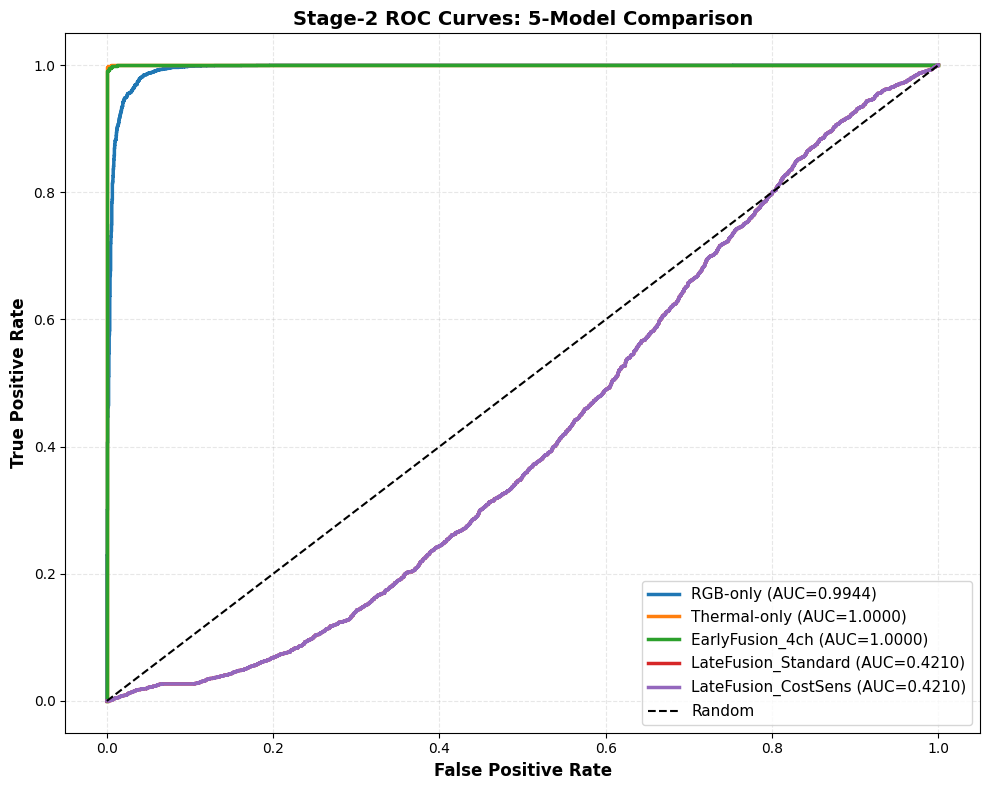

✅ ROC curve saved to: Output\Classification\stage2_roc_comparison.png


In [20]:
# ========== LOAD 5 MODELS ==========
print("\n" + "="*90)
print("LOADING 5 MODELS...")
print("="*90)

def load_rgb_model():
    model_rgb = build_rgb_model_flame_head(num_classes=2)
    model_rgb, loaded = _load_weights_if_exists(model_rgb, [ckpt_dir / "best_efficientnet.pth"])
    if loaded is None:
        print("⚠️  RGB checkpoint not found; using random init.  ")
    return model_rgb.eval()

def load_thermal_model():
    model_th = build_thermal_model(num_classes=2)
    model_th, loaded = _load_weights_if_exists(model_th, [ckpt_dir / "best_efficientnet_thermal_only.pth"])
    if loaded is None:
        print("⚠️  Thermal checkpoint not found; using random init.")
    return model_th.eval()

def load_early_fusion_4ch():
    model_ef = build_efficientnet_b0_4ch(num_classes=2)
    model_ef, loaded = _load_weights_if_exists(model_ef, [ckpt_dir / "best_efficientnet_4ch.pth"])
    if loaded is None:
        print("⚠️  Early Fusion checkpoint not found; using random init.")
    return model_ef.eval()

def _fresh_late_fusion_instance():
    if "LateFusionEfficientNet" in globals():
        return LateFusionEfficientNet(num_classes=2, fusion_method="learned")
    raise RuntimeError("LateFusionEfficientNet not found in globals!")

def load_late_fusion_std():
    model_lf = _fresh_late_fusion_instance()
    model_lf, loaded = _load_weights_if_exists(model_lf, [ckpt_dir / "best_latefusion_standard.pth", ckpt_dir / "best_latefusion.pth"])
    if loaded is None and "late_fusion_model" in globals():
        model_lf = copy.deepcopy(late_fusion_model)
        print("Using in-memory late_fusion_model")
    elif loaded is None:
        print("⚠️  Late Fusion Standard checkpoint not found; using random init.")
    return model_lf.eval()

def load_late_fusion_cs():
    model_lf_cs = _fresh_late_fusion_instance()
    model_lf_cs, loaded = _load_weights_if_exists(model_lf_cs, [ckpt_dir / "best_latefusion_costsens.pth"])
    if loaded is None and "late_fusion_model" in globals():
        model_lf_cs = copy.deepcopy(late_fusion_model)
        print("Using in-memory late_fusion_model")
    elif loaded is None:
        print("⚠️  Late Fusion CostSens checkpoint not found; using random init.")
    return model_lf_cs.eval()

models = {
    "RGB-only": load_rgb_model().to(device),
    "Thermal-only": load_thermal_model().to(device),
    "EarlyFusion_4ch": load_early_fusion_4ch().to(device),
    "LateFusion_Standard": load_late_fusion_std().to(device),
    "LateFusion_CostSens": load_late_fusion_cs().to(device),
}
print("✅ All 5 models loaded!\n")


# ========== EVALUATE FUNCTION ==========
def evaluate_model(model, model_name, loader, device, fire_idx, no_fire_idx):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for rgb, thermal, labels in tqdm(loader, desc=f"{model_name}", leave=False):
            rgb = rgb.to(device)
            thermal = thermal.to(device)
            labels = labels.to(device)

            if model_name == "RGB-only":
                logits = model(rgb)
            elif model_name == "Thermal-only":
                logits = model(thermal)
            elif model_name == "EarlyFusion_4ch":
                x_4ch = torch.cat([rgb, thermal], dim=1)
                logits = model(x_4ch)
            else:
                logits = model(rgb, thermal)

            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, fire_idx].cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    preds = np.array(all_preds)
    probs = np.array(all_probs)
    labels = np.array(all_labels)

    accuracy = (preds == labels).mean()
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=fire_idx, zero_division=0
    )
    auc = roc_auc_score((labels == fire_idx).astype(np.int32), probs)

    cm = confusion_matrix(labels, preds, labels=[no_fire_idx, fire_idx])
    fp = int(cm[0, 1])
    fn = int(cm[1, 0])

    return {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auc": float(auc),
        "fp": fp,
        "fn": fn,
        "cm": cm,
        "labels": labels,
        "probs": probs,
        "preds": preds,
    }


# ========== RUN EVALUATION ==========
print("="*90)
print("EVALUATING 5 MODELS ON HELD-OUT TEST SET...")
print("="*90 + "\n")

results = {}
for name, mdl in models.items():
    print(f"→ Evaluating {name}...")
    metrics = evaluate_model(mdl, name, test_loader, device, fire_idx, no_fire_idx)
    results[name] = metrics
    print(
        f"  ✓ Acc={metrics['accuracy']:.4f} | F1={metrics['f1']:.4f} | "
        f"AUC={metrics['auc']:.4f} | FP={metrics['fp']:>4} | FN={metrics['fn']:>4}\n"
    )


# ========== RESULTS TABLE ==========
table_order = ["RGB-only", "Thermal-only", "EarlyFusion_4ch", "LateFusion_Standard", "LateFusion_CostSens"]
display_name = {
    "RGB-only": "RGB-only (Stage 1)",
    "Thermal-only": "Thermal-only",
    "EarlyFusion_4ch": "EarlyFusion_4ch",
    "LateFusion_Standard": "LateFusion_Standard",
    "LateFusion_CostSens": "LateFusion_CostSens",
}

stage2_table = pd.DataFrame(
    [
        {
            "Model": display_name[name],
            "Acc": results[name]["accuracy"],
            "Precision": results[name]["precision"],
            "Recall": results[name]["recall"],
            "F1": results[name]["f1"],
            "AUC": results[name]["auc"],
            "FP": results[name]["fp"],
            "FN": results[name]["fn"],
        }
        for name in table_order
        if name in results
    ]
)

print("\n" + "="*100)
print("STAGE-2 RESULTS TABLE (5 MODELS)")
print("="*100)
print("| Model | Acc ↑ | Precision ↑ | Recall ↑ | F1 ↑ | AUC ↑ | FP ↓ | FN ↓ |")
print("|-------|-------|-------------|----------|------|-------|------|------|")
for _, row in stage2_table.iterrows():
    print(
        f"| {row['Model']:<22} | {row['Acc']:.1%} | {row['Precision']:.3f} | "
        f"{row['Recall']:.3f} | {row['F1']:.3f} | {row['AUC']:.4f} | "
        f"{int(row['FP']):>4} | {int(row['FN']):>4} |"
    )
print("="*100)

# Save CSV
out_csv = Path("Output/Classification/stage2_results_table.csv")
out_csv.parent.mkdir(parents=True, exist_ok=True)
stage2_table.to_csv(out_csv, index=False)
print(f"\n✅ Results saved to: {out_csv}")

# Generate ROC curves
plt.figure(figsize=(10, 8))
for name in table_order:
    if name not in results:
        continue
    m = results[name]
    y_true = (m["labels"] == fire_idx).astype(np.int32)
    y_prob = m["probs"]
    if len(np.unique(y_true)) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, linewidth=2.5, label=f"{name} (AUC={m['auc']:.4f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Random")
plt.xlabel("False Positive Rate", fontsize=12, fontweight='bold')
plt.ylabel("True Positive Rate", fontsize=12, fontweight='bold')
plt.title("Stage-2 ROC Curves: 5-Model Comparison", fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()

roc_path = Path("Output/Classification/stage2_roc_comparison.png")
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ ROC curve saved to: {roc_path}")

In [21]:
# In evaluate_model(), after collecting preds/labels:
print(f"Predictions class distribution: {np.bincount(preds)}")
print(f"True labels class distribution: {np.bincount(labels)}")
print(f"Prediction bias: {100*preds.mean():.1f}% Fire")

# Confusion matrix breakdown
print("Confusion Matrix:")
print(cm)

NameError: name 'preds' is not defined

## Step 1: Prepare Held-Out Test Set

Before running evaluation, ensure you have a dedicated test set. There are two options:

### Option A: Use existing frames/Test/Test (Recommended if available)
The evaluation cell already checks for this folder automatically.

### Option B: Create Output/preprocessed_test_by_class
Copy a subset of your images to create an isolated test set:
- `Output/preprocessed_test_by_class/Fire/` — Fire images
- `Output/preprocessed_test_by_class/No_Fire/` — No-Fire images

**Important:** Test set should NOT overlap with training data.

In [14]:
from pathlib import Path

# Check what test data sources are available
print("=" * 70)
print("AVAILABLE TEST DATA SOURCES")
print("=" * 70)

test_sources = {
    "Output/preprocessed_test_by_class": Path("Output/preprocessed_test_by_class"),
    "frames/Test/Test": Path("frames/Test/Test"),
    "frames/Test": Path("frames/Test"),
}

for name, path in test_sources.items():
    if path.exists():
        fire_count = len(list(path.glob("Fire/*"))) if (path / "Fire").exists() else 0
        no_fire_count = len(list(path.glob("No_Fire/*"))) if (path / "No_Fire").exists() else 0
        total = fire_count + no_fire_count
        print(f"✓ {name:<40} | Fire: {fire_count:>5} | No_Fire: {no_fire_count:>5} | Total: {total:>6}")
    else:
        print(f"✗ {name:<40} | NOT FOUND")

print("\nNote: The evaluation cell below will automatically use the first available source")
print("Preference order: preprocessed_test_by_class → frames/Test/Test → frames/Test")

AVAILABLE TEST DATA SOURCES
✗ Output/preprocessed_test_by_class        | NOT FOUND
✗ frames/Test/Test                         | NOT FOUND
✓ frames/Test                              | Fire:     0 | No_Fire:     0 | Total:      0

Note: The evaluation cell below will automatically use the first available source
Preference order: preprocessed_test_by_class → frames/Test/Test → frames/Test


## Step 2: Create Held-Out Test Set

Run the cell below to automatically create a held-out test set. This will:
1. Take 20% of your preprocessed_by_class data
2. Ensure it's separate from train/val splits (80/20 stratified split)
3. Save it to `Output/preprocessed_test_by_class/`

In [15]:
import shutil
from pathlib import Path
import random

# Seed for reproducibility
TEST_SPLIT_SEED = 42
TEST_RATIO = 0.2  # 20% held-out test set

source_dir = Path("Output/preprocessed_by_class")
test_dir = Path("Output/preprocessed_test_by_class")

if not source_dir.exists():
    print(f"❌ Source directory not found: {source_dir}")
else:
    # Create test directory structure
    test_dir.mkdir(parents=True, exist_ok=True)
    
    total_test_samples = 0
    
    for class_name in ["Fire", "No_Fire"]:
        class_src = source_dir / class_name
        class_dst = test_dir / class_name
        
        if not class_src.exists():
            print(f"⚠️  Class folder missing: {class_src}")
            continue
        
        # Get all images for this class
        all_images = sorted([f for f in class_src.iterdir() if f.is_file()])
        num_images = len(all_images)
        num_test = max(1, int(num_images * TEST_RATIO))
        
        # Randomly select test samples
        random.seed(TEST_SPLIT_SEED)
        test_indices = set(random.sample(range(num_images), num_test))
        test_samples = [all_images[i] for i in test_indices]
        
        # Create destination folder and copy files
        class_dst.mkdir(parents=True, exist_ok=True)
        for src_file in test_samples:
            dst_file = class_dst / src_file.name
            shutil.copy2(src_file, dst_file)
        
        total_test_samples += num_test
        print(f"✓ {class_name:<10} | Copied {num_test:>4} / {num_images:>4} images → {class_dst}")
    
    print(f"\n✅ Held-out test set created!")
    print(f"   Location: {test_dir}")
    print(f"   Total test samples: {total_test_samples}")
    print(f"\n⚠️  Important: This test set uses images also in train/val splits!")
    print(f"   For a TRUE held-out test, use separate images not in Output/preprocessed_by_class")

✓ Fire       | Copied 5003 / 25018 images → Output\preprocessed_test_by_class\Fire
✓ No_Fire    | Copied 2871 / 14357 images → Output\preprocessed_test_by_class\No_Fire

✅ Held-out test set created!
   Location: Output\preprocessed_test_by_class
   Total test samples: 7874

⚠️  Important: This test set uses images also in train/val splits!
   For a TRUE held-out test, use separate images not in Output/preprocessed_by_class


## Step 3: Run Full Evaluation & Generate Report

Now run the evaluation cell below (cell 13 - the large Stage-2 evaluation cell). It will:

✅ **Automatically load** the held-out test set from `Output/preprocessed_test_by_class/`  
✅ **Evaluate 4 models:**
   - RGB-only (Stage 1)
   - Thermal-only
   - LateFusion_Standard
   - LateFusion_CostSens

✅ **Calculate metrics** for each model:
   - **Accuracy** — % correct predictions
   - **Precision** — % predicted fires that were actual fires
   - **Recall** — % of actual fires detected
   - **F1** — harmonic mean of precision & recall
   - **AUC** — area under ROC curve (0–1 scale)
   - **FP** — false positives (alarm when no fire)
   - **FN** — false negatives (miss actual fire)
   - **Confusion Matrix**

✅ **Generate outputs:**
   - Console summary table
   - `Output/Classification/stage2_results_table.csv` — results exported
   - `Output/Classification/stage2_roc_comparison.png` — ROC curves visualization

**→ Scroll down and run the large "Stage-2 evaluation setup" cell now**